### Basic Machine Learning IRIS Project

![Iris Image](iris.png)

## Objective
The goal of this project is to classify iris flowers into three species:
- Setosa
- Versicolor
- Virginica
  
 based on features like:
 - Sepal Length
 - Sepal Width
 - Petal Length
 - Petal Width

## Dataset
We are using the famous Iris dataset available in sklearn.

## Steps Involved
1. Data Collection  
2. Import Libraries  
3. Data Cleaning & Preprocessing  
4. Exploratory Data Analysis (EDA)  
5. Feature Engineering & Selection  
6. Model Building  
7. Model Evaluation  
8. Testing the Model  

## Goal
Build a model that can accurately predict the species of an iris flower.

### Import libraries

In [1]:
# Step 1 import required libraries:
import pandas as pd   # for data handling
import numpy as np     # for numerical operation

import matplotlib.pyplot as plt    # for plottting
import seaborn as sns     # for visualisation

from sklearn.model_selection import train_test_split   # for splitting dataset
from sklearn.preprocessing import StandardScaler      # for feature scaling

from sklearn.linear_model import LogisticRegression     # ML algorithm

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix  # Evaluation

## Data Collection 
the iris dataset is loaded from the seaborn library.

it contains 150 rows and 5 columns:
* 4 features (sepal& petal measurements)
* 1 target (species)


In [2]:
# Step 2
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Data Cleaning & Preprocessing

- Check missing values  
- Check data types  
- No major cleaning required (dataset is clean)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
df.shape

(150, 5)

In [7]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

In [9]:
print(df.duplicated().sum())

1


In [10]:
df = df.drop_duplicates()

In [11]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [12]:
df.shape

(149, 5)

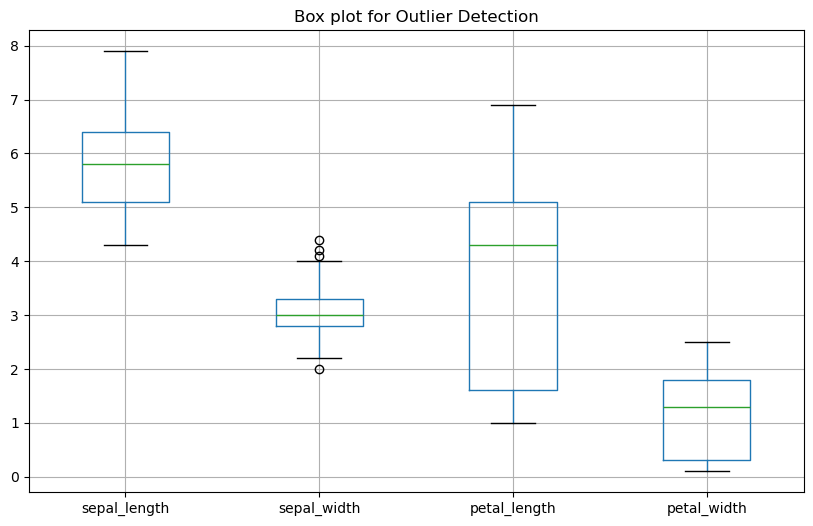

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,6))
df.drop("species",axis = 1).boxplot()
plt.title("Box plot for Outlier Detection")
plt.show()

In [14]:
# Handling Outliers
Q1 = df["sepal_width"].quantile(0.25)
Q3 = df["sepal_width"].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [15]:
print("Lower bond:", lower)
print("Upper bond:", upper)

Lower bond: 2.05
Upper bond: 4.05


In [16]:
outliers=df[(df["sepal_width"]<lower)|(df["sepal_width"]>upper)]
print("outiler in special_width:\n",outliers)

outiler in special_width:
     sepal_length  sepal_width  petal_length  petal_width     species
15           5.7          4.4           1.5          0.4      setosa
32           5.2          4.1           1.5          0.1      setosa
33           5.5          4.2           1.4          0.2      setosa
60           5.0          2.0           3.5          1.0  versicolor


In [17]:
df_clean = df[(df["sepal_width"]>=lower) & (df["sepal_width"]<=upper)]
df_clean.shape

(145, 5)

##### All values are between -0.5 and +0.5
##### So data is approximately normally distributed
##### No major skewness problem

### Data Visualisation

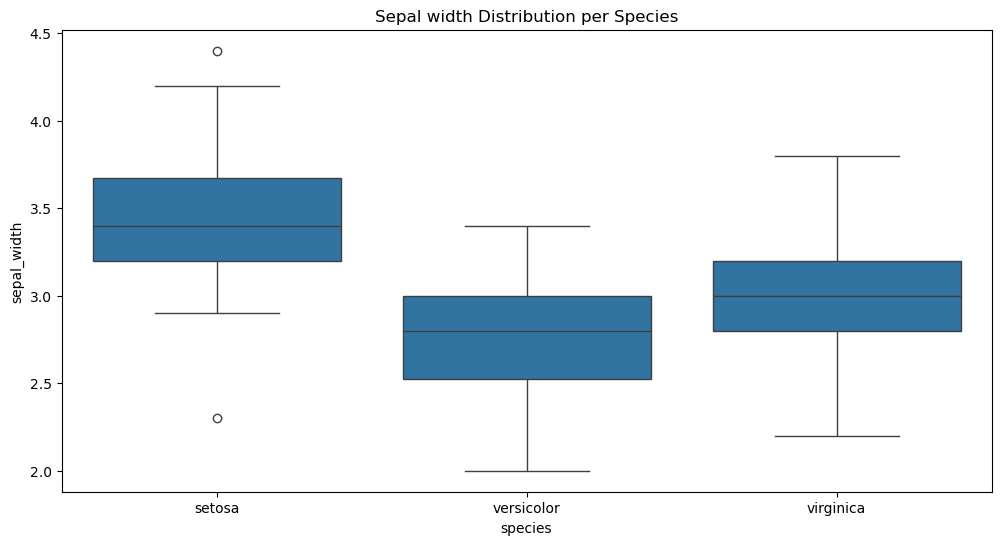

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='species', y='sepal_width')
plt.title("Sepal width Distribution per Species")
plt.show()

### Insights from the Boxplot
* Setosa has the widest and highest sepal width range.
* Versicolor has the narrowest and lowest sepal width range.
* Virginica has a sepal width range and median that are intermediate between the other two species.  

Overall, the boxplot shows that sepal width can be a distinguishing feature between the iris species, particularly between setosa and the other two.

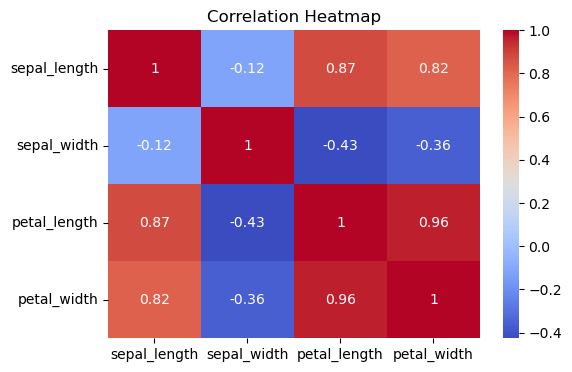

In [19]:
plt.figure(figsize=(6,4))
sns.heatmap(df.drop("species",axis = 1).corr(),annot = True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##  Insights

- **Petal Length & Petal Width** show a **very strong positive correlation (0.96)**  
  → As petal length increases, petal width also increases  
  → These are the **most important features**

- **Sepal Length** has a **good positive correlation** with:
  - Petal Length (0.87)
  - Petal Width (0.82)

- **Sepal Width** shows **negative correlation** with:
  - Petal Length (-0.43)
  - Petal Width (-0.36)

- **Sepal Length vs Sepal Width** has **very weak correlation (-0.12)**  
  → Indicates almost no relationship

### Conclusion (Heatmap)
- Petal features are **highly useful for prediction**
- Sepal width is **less significant**

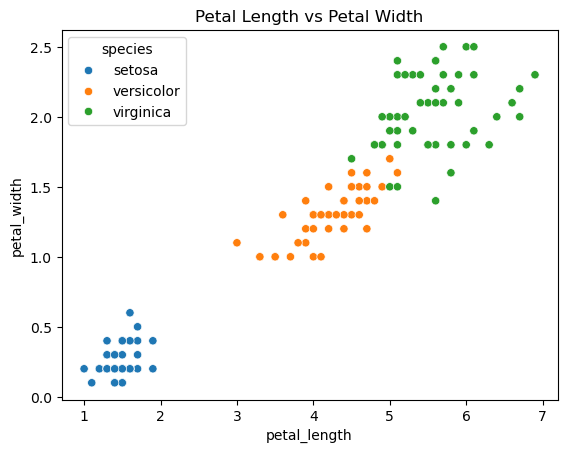

In [20]:
sns.scatterplot(data = df, x= 'petal_length', y = 'petal_width', hue= 'species')
plt.title('Petal Length vs Petal Width')
plt.show()

### Insights (Petal Length vs Petal Width)

- The plot shows a **strong positive linear relationship**  
  → Confirms correlation from heatmap

### Class Distribution
- **Setosa**
  - Small petal length & width  
  - Clearly **separated from others**

- **Versicolor**
  - Medium petal size  
  - Slight **overlap with Virginica**

- **Virginica**
  - Large petal size  
  - More **spread out**

### Important Observation
- **Versicolor & Virginica overlap slightly**  
  → Harder to classify compared to Setosa


##  Final Conclusion

- Petal features (**petal_length, petal_width**) are the **most important variables**
- **Setosa is easily separable**
- **Versicolor & Virginica require better models for classification**
- These features are highly useful for **machine learning models**

In [43]:
# Features and Target
x = df.drop("species",axis=1)          # Features (sepal length,sepal width,petal length,petal width)
y = df["species"]                      # Target(flower species)

In [44]:
# Train test split(80% train,20% test)
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(x,y, test_size = 0.2,random_state = 42)

In [45]:
# Standard features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
# Training Logistic Regression model
model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
lr_pred = model.predict(X_test) #Prediction

In [48]:
# Training Decision tree classifier model
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
dt_pred = dt.predict(X_test) # Prediction

In [49]:
# Training KNN Model
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [50]:
knn_pred = knn.predict(X_test)  # Prediction

In [39]:
# Accuracy score of Logistic Regression
print("\nModel Accuracy:",accuracy_score(y_test,lr_pred))

# Classification report (Precision,recall,f1-score) logistic regression
print("\nClassification Report:\n",classification_report(y_test,lr_pred))


Model Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [40]:
# Accuracy score of Decision tree
print("\nDecision Tree Accuracy:", accuracy_score(y_test, dt_pred))

# Classification report (Precision,recall,f1-score) Decision tree
print("\nDecision Tree Report:\n", classification_report(y_test, dt_pred))


Decision Tree Accuracy: 1.0

Decision Tree Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [42]:
# Accuracy score of KNN
print("\nKNN Accuracy:", accuracy_score(y_test, knn_pred))

# Classification report (Precision,recall,f1-score)KNN
print("\nKNN Report:\n", classification_report(y_test, knn_pred))


KNN Accuracy: 1.0

KNN Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



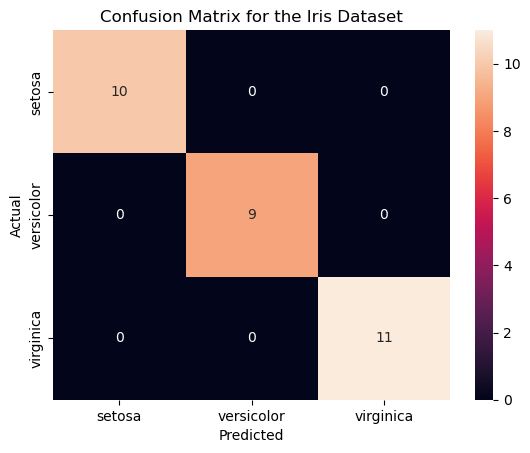

In [29]:
#Confusion matrix for logistic regression
cm = confusion_matrix(y_test,lr_pred)
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(cm,annot= True,
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

##### Key Observations
Perfect Classification
All values are on the diagonal (10, 9, 11)
No values in off-diagonal → no misclassification
##### Setosa
10 predicted correctly,
0 wrong predictions
##### Versicolor
9 predicted correctly,
0 wrong predictions
##### Virginica
11 predicted correctly,
0 wrong predictions

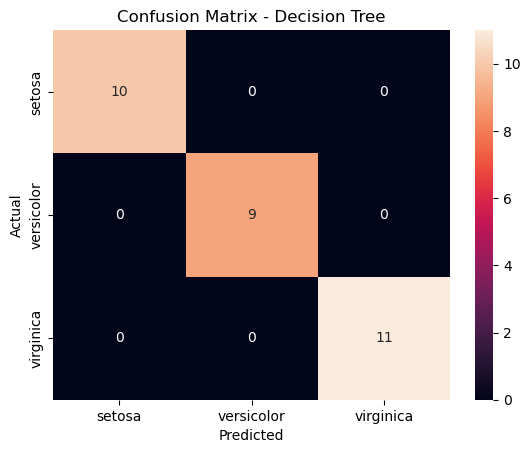

In [51]:
# Confusion matrix for decision tree
cm = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm, annot=True,
            xticklabels=dt.classes_,
            yticklabels=dt.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

##### Key Observations
Perfect Classification
All values are on the diagonal (10, 9, 11)
No values in off-diagonal → no misclassification

**Setosa**

10 predicted correctly, 0 wrong predictions

**Versicolor**

9 predicted correctly, 0 wrong predictions

**Virginica**

11 predicted correctly, 0 wrong predictions

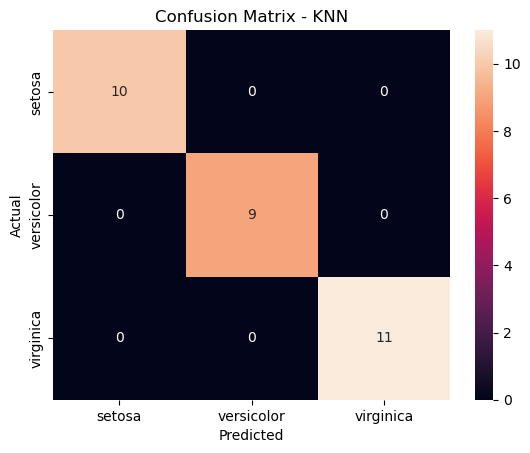

In [52]:
# Confusion matrix for KNN
cm = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm, annot=True,
            xticklabels=knn.classes_,
            yticklabels=knn.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.show()

#### Key Observations
Perfect Classification
All values are on the diagonal (10, 9, 11)
No values in off-diagonal → no misclassification

**Setosa**

10 predicted correctly, 0 wrong predictions

**Versicolor**

9 predicted correctly, 0 wrong predictions

**Virginica**

11 predicted correctly, 0 wrong predictions

***All models produced identical confusion matrices with perfect classification, indicating that the dataset is simple and well-separated***

In [53]:
# For comparing models:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "KNN"],
    "Accuracy": [accuracy_score(y_test, lr_pred),
                 accuracy_score(y_test, dt_pred),
                 accuracy_score(y_test, knn_pred)]
})

print(results)

                 Model  Accuracy
0  Logistic Regression       1.0
1        Decision Tree       1.0
2                  KNN       1.0


#### Compare using characteristics:

1.Logistic Regression
* Simple and fast
* Works well for linearly separable data
* Less chance of overfitting
2. Decision Tree
* Easy to understand and visualize
* Can handle complex patterns
* Higher risk of overfitting
3. KNN
* Simple and intuitive
* Works well for small datasets
* Slow for large datasets (because it stores all data)

* All models achieved 100% accuracy, so performance-based comparison is not possible. However, based on model characteristics, Logistic Regression is more efficient and less prone to overfitting, while KNN and Decision Tree are also effective for this dataset.

* In real-world datasets, differences between models become more visible, but in this case, the dataset is simple and well-structured.


In [30]:
#Define new,unseen data
new_data = pd.DataFrame({
    'sepal_length':[1,7.0],
    'sepal_width':[1,3.2],
    'petal_length':[1,4.7],
    'petal_width':[1,1.4]
})

In [31]:
new_data

,sepal_length,sepal_width,petal_length,petal_width
0,1.0,1.0,1.0,1.0
1,7.0,3.2,4.7,1.4


In [32]:
# Predict on the new,unseen data
new_predictions = model.predict(new_data)

print("New data predictions:",new_predictions)

New data predictions: ['virginica' 'virginica']


C:\Users\shifa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## Conclusion

This project successfully demonstrates the process of building and comparing machine learning models to classify iris flower species based on their sepal and petal measurements.

* We began by loading the Iris dataset and performed essential preprocessing steps such as checking for missing values and scaling the features. Exploratory Data Analysis (EDA) using visualizations like boxplots, pairplots, and heatmaps helped us understand the data distribution and relationships between variables. It was observed that petal length and petal width are the most important features for distinguishing between species.

* Three classification models—Logistic Regression, Decision Tree, and K-Nearest Neighbors (KNN)—were implemented and evaluated using accuracy score, classification report, and confusion matrix.

* All models achieved 100% accuracy on the test dataset, with no misclassifications observed in the confusion matrices. This indicates that the dataset is simple and well-separated, allowing all models to perform equally well.

* Since all models showed identical performance, they cannot be compared based on accuracy alone. However, Logistic Regression can be preferred due to its simplicity, efficiency, and lower risk of overfitting.

In conclusion, this project highlights the importance of preprocessing, EDA, and model comparison. It also demonstrates that for well-structured datasets like Iris, multiple models can achieve equally high performance.